In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_user_segmentation.csv to ecommerce_user_segmentation.csv


In [3]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (10000, 14)

Column Names:
['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Campaign_Response', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns', 'Segment_Label']

Data Types:
Customer_ID              object
Recency                   int64
Frequency                 int64
Monetary                  int64
Avg_Order_Value           int64
Session_Count             int64
Avg_Session_Duration    float64
Pages_Viewed              int64
Clicks                    int64
Campaign_Response         int64
Wishlist_Adds             int64
Cart_Abandon_Rate       float64
Returns                   int64
Segment_Label            object
dtype: object

Missing Values:
Customer_ID             0
Recency                 0
Frequency               0
Monetary                0
Avg_Order_Value         0
Session_Count           0
Avg_Session_Duration    0
Pages_Viewed            0
Clicks                  0
Campaig

In [5]:
df.describe()

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.665400,28.783000,1938.394600,146.599900,55.915800,15.444645,33.99840,1211.465100,0.416700,28.618300,17.653052,7.268800
std,37.818734,23.133669,2327.840348,87.564246,43.551484,8.133285,21.14206,1058.875362,0.493037,23.544257,10.013803,5.623247
min,1.000000,0.000000,0.000000,10.000000,0.000000,1.000433,1.00000,50.000000,0.000000,0.000000,0.007050,0.000000
25%,22.000000,10.000000,269.000000,79.000000,22.000000,9.515457,18.00000,451.750000,0.000000,11.000000,10.829601,3.000000
50%,40.000000,20.000000,1022.000000,135.000000,44.000000,14.305176,30.00000,871.000000,0.000000,21.000000,15.908491,6.000000
75%,63.000000,40.000000,2825.250000,196.000000,75.000000,19.725305,46.00000,1518.000000,1.000000,41.000000,22.769516,11.000000
max,179.000000,99.000000,9995.000000,399.000000,199.000000,39.995729,99.00000,4998.000000,1.000000,99.000000,49.994254,24.000000


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Session_Count",
    "Avg_Session_Duration",
    "Pages_Viewed",
    "Clicks",
    "Campaign_Response",
    "Wishlist_Adds",
    "Cart_Abandon_Rate",
    "Returns"
]

X = df[features].copy()

X.head()

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns
0,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8
1,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9
2,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16
3,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0
4,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8


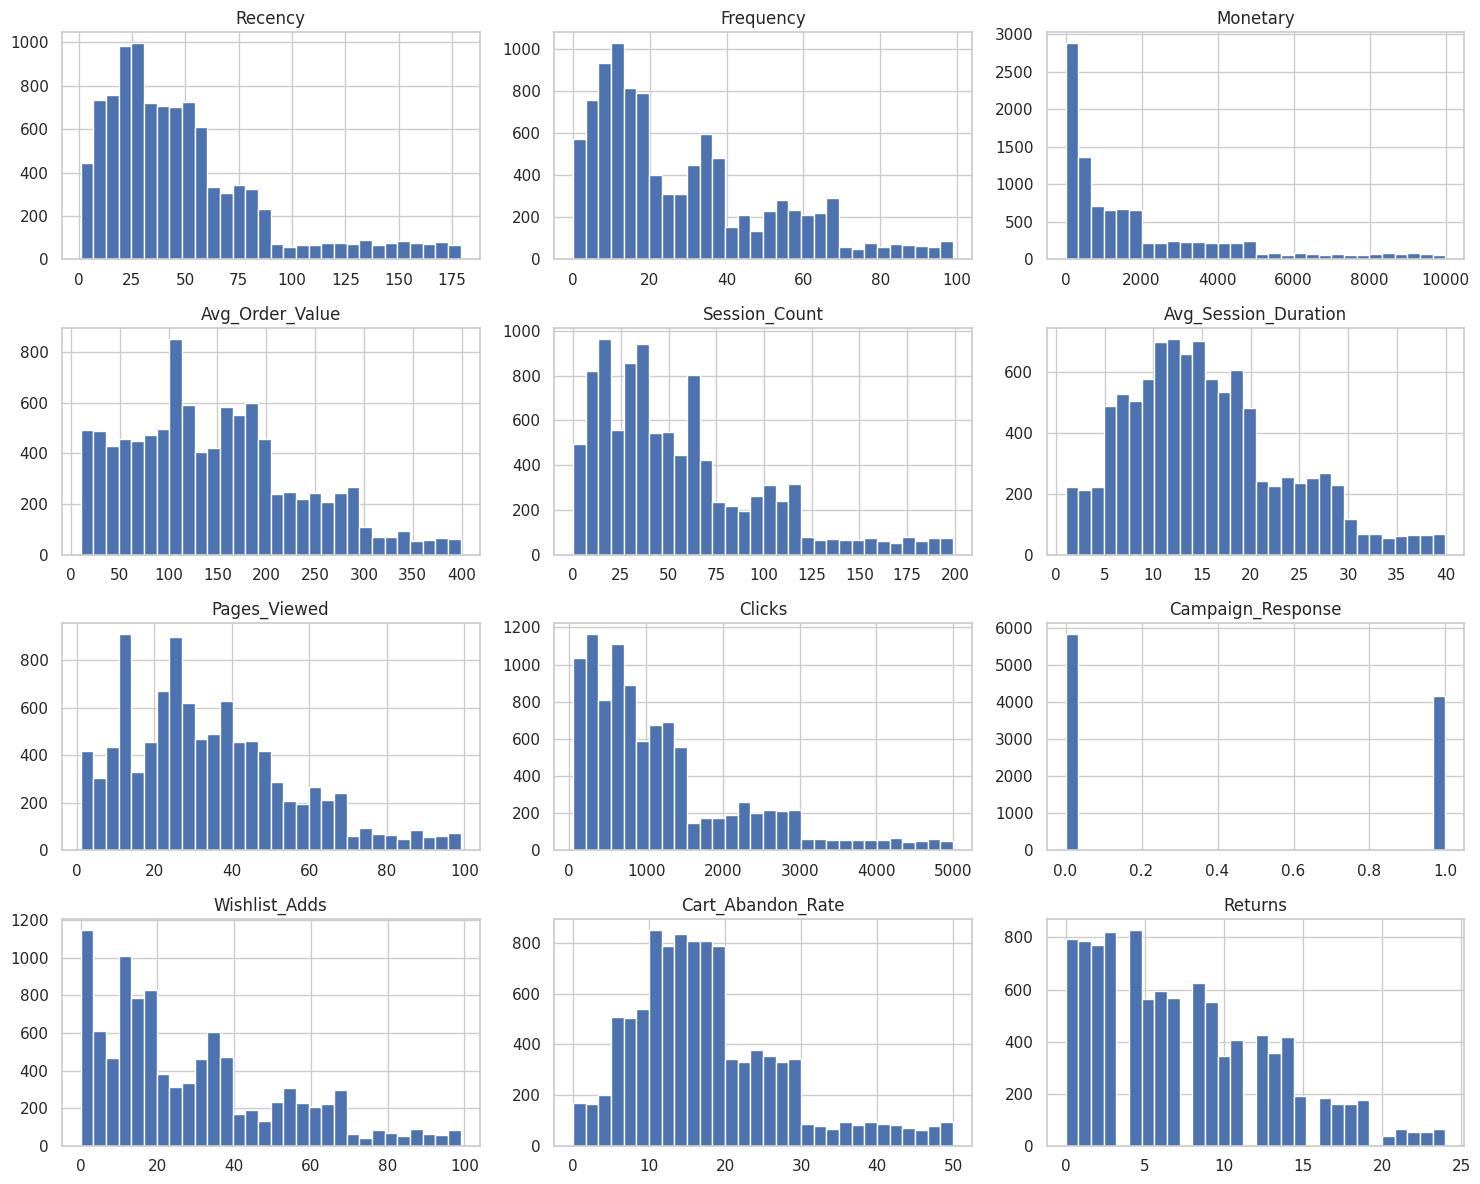

In [8]:
X.hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()

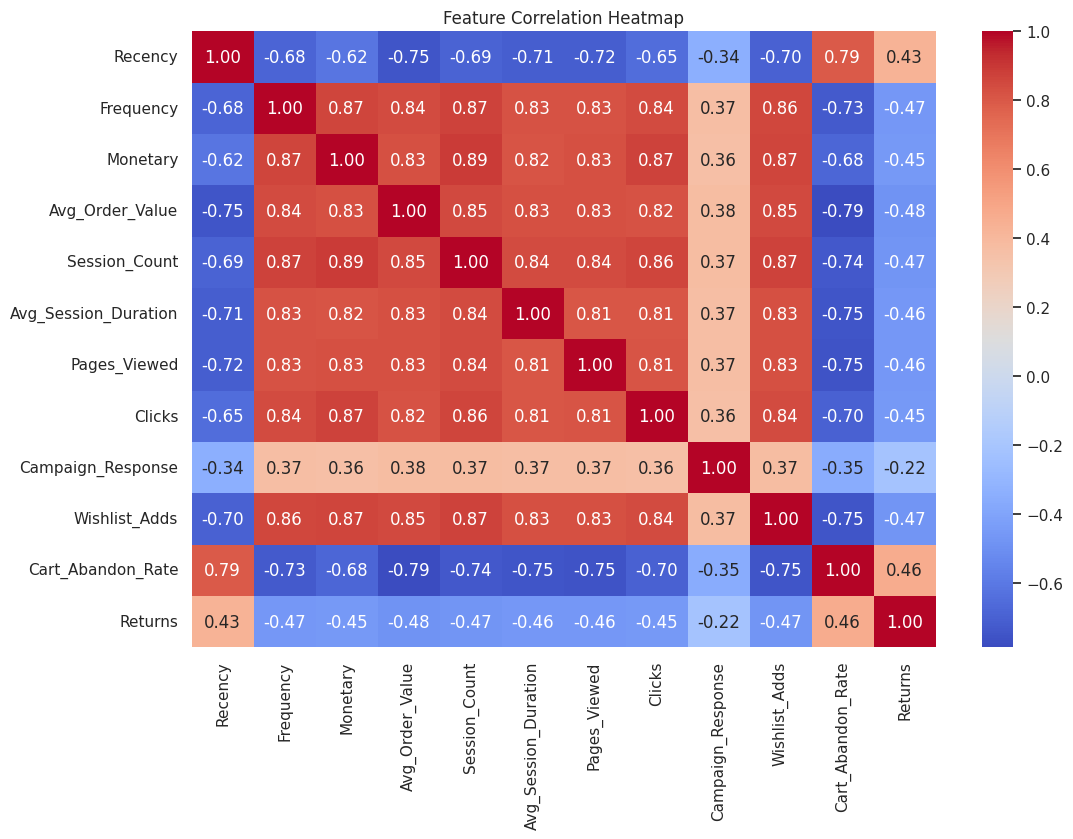

In [9]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
numeric_features = features

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features)
])

In [11]:
X_processed = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Processed shape:", X_processed.shape)

Original shape: (10000, 12)
Processed shape: (10000, 12)


In [12]:
inertias = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_processed)

    inertias.append(kmeans.inertia_)

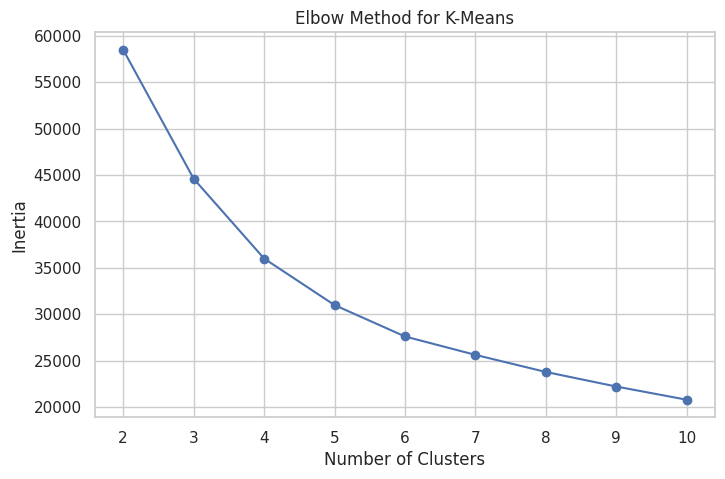

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

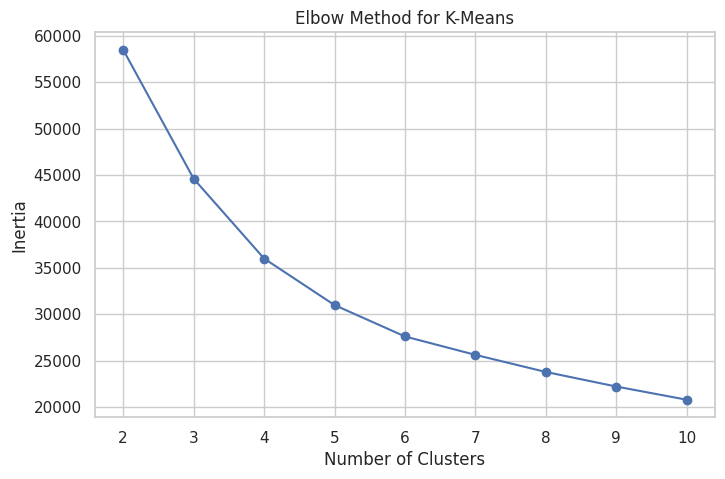

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

In [16]:
kmeans_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("clustering", KMeans(
        n_clusters=5,
        random_state=42,
        n_init=10
    ))
])

In [17]:
kmeans_labels = kmeans_pipeline.fit_predict(X)

df["KMeans_Cluster"] = kmeans_labels

df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label,KMeans_Cluster
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver,4
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron,2
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper,4
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver,1
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold,3


In [18]:
kmeans_score = silhouette_score(
    X_processed,
    kmeans_labels
)

kmeans_db = davies_bouldin_score(
    X_processed,
    kmeans_labels
)

kmeans_ch = calinski_harabasz_score(
    X_processed,
    kmeans_labels
)

print("K-Means Results")
print("----------------")
print("Silhouette Score:", round(kmeans_score, 4))
print("Davies-Bouldin Index:", round(kmeans_db, 4))
print("Calinski-Harabasz Score:", round(kmeans_ch, 4))

K-Means Results
----------------
Silhouette Score: 0.3022
Davies-Bouldin Index: 1.2639
Calinski-Harabasz Score: 7175.6859


In [19]:
sample_size = min(1000, len(X_processed))

sample_indices = np.random.RandomState(42).choice(
    len(X_processed),
    sample_size,
    replace=False
)

X_sample = X_processed[sample_indices]

In [20]:
linked = linkage(
    X_sample,
    method="ward"
)

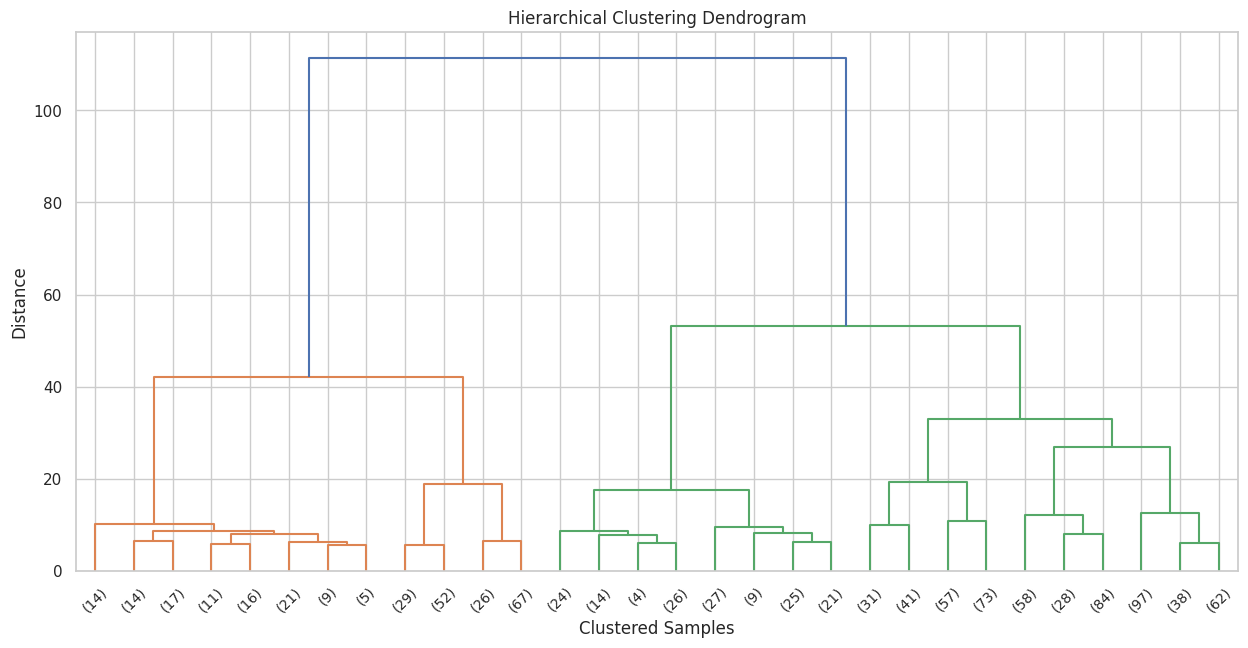

In [21]:
plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clustered Samples")
plt.ylabel("Distance")

plt.show()

In [22]:
hierarchical_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("clustering", AgglomerativeClustering(
        n_clusters=5,
        linkage="ward"
    ))
])

In [23]:
hierarchical_labels = hierarchical_pipeline.fit_predict(X)

df["Hierarchical_Cluster"] = hierarchical_labels

df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label,KMeans_Cluster,Hierarchical_Cluster
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver,4,4
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron,2,2
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper,4,4
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver,1,0
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold,3,1


In [24]:
hier_score = silhouette_score(
    X_processed,
    hierarchical_labels
)

hier_db = davies_bouldin_score(
    X_processed,
    hierarchical_labels
)

hier_ch = calinski_harabasz_score(
    X_processed,
    hierarchical_labels
)

print("Hierarchical Clustering Results")
print("--------------------------------")
print("Silhouette Score:", round(hier_score, 4))
print("Davies-Bouldin Index:", round(hier_db, 4))
print("Calinski-Harabasz Score:", round(hier_ch, 4))

Hierarchical Clustering Results
--------------------------------
Silhouette Score: 0.3028
Davies-Bouldin Index: 1.2637
Calinski-Harabasz Score: 7140.1959


In [25]:
dbscan_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("clustering", DBSCAN(
        eps=1.5,
        min_samples=10
    ))
])

In [26]:
dbscan_labels = dbscan_pipeline.fit_predict(X)

df["DBSCAN_Cluster"] = dbscan_labels

df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver,4,4,0
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron,2,2,1
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper,4,4,0
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver,1,0,1
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold,3,1,1


In [27]:
unique_clusters = sorted(set(dbscan_labels))

print("Clusters:", unique_clusters)

print(
    "Number of clusters:",
    len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
)

print(
    "Number of noise points:",
    np.sum(dbscan_labels == -1)
)

Clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Number of clusters: 4
Number of noise points: 145


In [28]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:

    db_score = silhouette_score(
        X_processed[mask],
        dbscan_labels[mask]
    )

    db_db = davies_bouldin_score(
        X_processed[mask],
        dbscan_labels[mask]
    )

    db_ch = calinski_harabasz_score(
        X_processed[mask],
        dbscan_labels[mask]
    )

    print("DBSCAN Results")
    print("--------------")
    print("Silhouette Score:", round(db_score, 4))
    print("Davies-Bouldin Index:", round(db_db, 4))
    print("Calinski-Harabasz Score:", round(db_ch, 4))

else:

    db_score = np.nan
    db_db = np.nan
    db_ch = np.nan

    print("DBSCAN did not produce enough clusters for evaluation.")

DBSCAN Results
--------------
Silhouette Score: 0.1393
Davies-Bouldin Index: 1.5106
Calinski-Harabasz Score: 1127.5624


In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

Explained variance: [0.71945984 0.06847803]


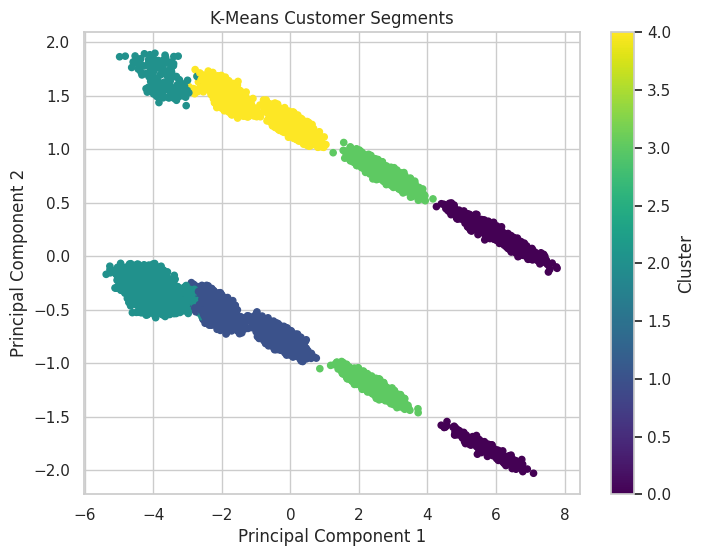

In [30]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Segments")

plt.colorbar(scatter, label="Cluster")

plt.show()

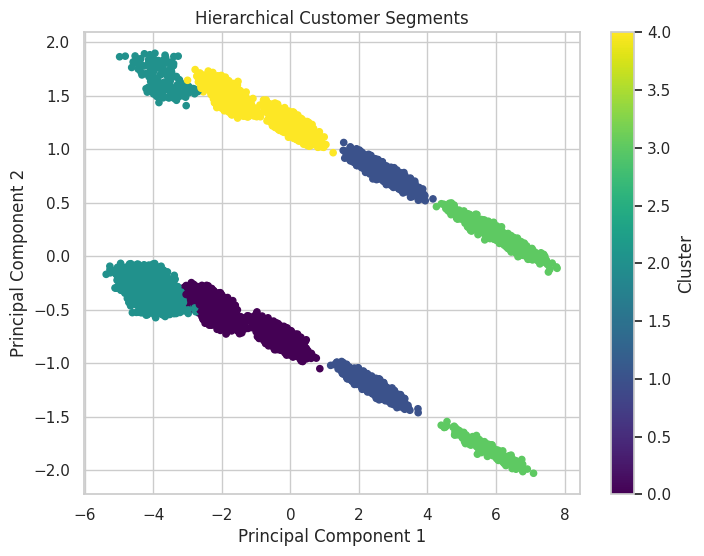

In [31]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    cmap="viridis",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Customer Segments")

plt.colorbar(scatter, label="Cluster")

plt.show()

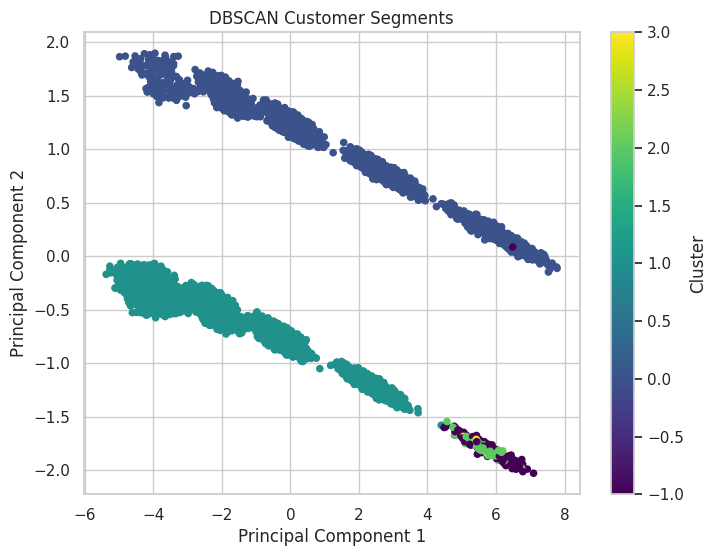

In [32]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Customer Segments")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [33]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],

    "Silhouette Score": [
        kmeans_score,
        hier_score,
        db_score
    ],

    "Davies-Bouldin Index": [
        kmeans_db,
        hier_db,
        db_db
    ],

    "Calinski-Harabasz Score": [
        kmeans_ch,
        hier_ch,
        db_ch
    ]
})

comparison

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,0.302183,1.263925,7175.685915
1,Hierarchical,0.302789,1.263669,7140.195892
2,DBSCAN,0.139346,1.510551,1127.562383


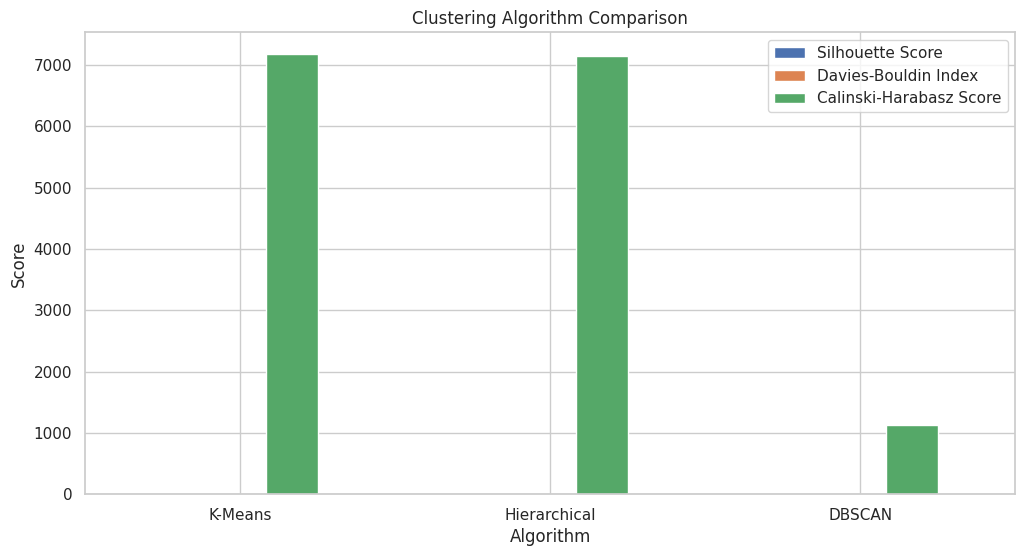

In [34]:
comparison.set_index("Algorithm")[
    [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Clustering Algorithm Comparison")
plt.ylabel("Score")

plt.xticks(rotation=0)
plt.legend()

plt.show()

In [35]:
cluster_sizes = (
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers in Each Cluster:")

display(
    cluster_sizes.to_frame("Customer Count")
)

Customers in Each Cluster:


,Customer Count
KMeans_Cluster,
0,1031
1,3421
2,1552
3,2024
4,1972


In [36]:
cluster_profile = (
    df.groupby("KMeans_Cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns
KMeans_Cluster,,,,,,,,,,,,
0,7.51,74.10,7478.51,299.37,149.06,29.90,74.05,3476.15,0.80,74.23,5.01,2.04
1,48.39,18.64,794.49,118.84,37.67,12.67,27.49,762.01,0.00,18.85,18.37,7.95
2,117.30,5.04,67.88,32.24,10.59,5.66,8.08,198.53,0.09,2.72,34.49,12.16
3,19.52,49.54,3506.56,223.53,89.20,22.43,49.31,1980.84,0.61,49.80,9.89,4.46
4,46.55,20.07,888.96,125.93,40.38,13.23,29.03,814.69,1.00,20.36,17.73,7.86


In [37]:
for cluster in cluster_profile.index:

    print(f"\nCluster {cluster}")

    print(
        cluster_profile.loc[cluster]
    )


Cluster 0
Recency                    7.51
Frequency                 74.10
Monetary                7478.51
Avg_Order_Value          299.37
Session_Count            149.06
Avg_Session_Duration      29.90
Pages_Viewed              74.05
Clicks                  3476.15
Campaign_Response          0.80
Wishlist_Adds             74.23
Cart_Abandon_Rate          5.01
Returns                    2.04
Name: 0, dtype: float64

Cluster 1
Recency                  48.39
Frequency                18.64
Monetary                794.49
Avg_Order_Value         118.84
Session_Count            37.67
Avg_Session_Duration     12.67
Pages_Viewed             27.49
Clicks                  762.01
Campaign_Response         0.00
Wishlist_Adds            18.85
Cart_Abandon_Rate        18.37
Returns                   7.95
Name: 1, dtype: float64

Cluster 2
Recency                 117.30
Frequency                 5.04
Monetary                 67.88
Avg_Order_Value          32.24
Session_Count            10.59
Avg_Sess

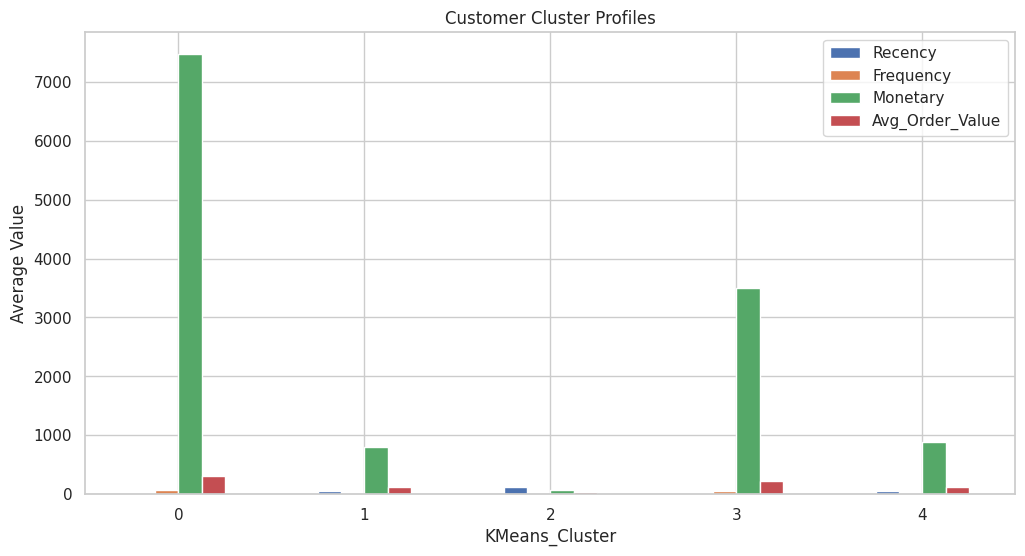

In [38]:
cluster_profile[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Avg_Order_Value"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Customer Cluster Profiles")
plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.show()

In [39]:
profile = cluster_profile.copy()

for cluster in profile.index:

    recency = profile.loc[cluster, "Recency"]
    frequency = profile.loc[cluster, "Frequency"]
    monetary = profile.loc[cluster, "Monetary"]

    print(f"\nCluster {cluster}")

    print(
        f"Recency: {recency:.2f}"
    )

    print(
        f"Frequency: {frequency:.2f}"
    )

    print(
        f"Monetary: {monetary:.2f}"
    )

    if monetary > profile["Monetary"].median() and frequency > profile["Frequency"].median():
        print("Interpretation: High-value and frequent customers.")

    elif monetary > profile["Monetary"].median():
        print("Interpretation: Higher-spending customers.")

    elif recency > profile["Recency"].median():
        print("Interpretation: Customers who have not purchased recently.")

    else:
        print("Interpretation: Lower-value or moderately active customers.")


Cluster 0
Recency: 7.51
Frequency: 74.10
Monetary: 7478.51
Interpretation: High-value and frequent customers.

Cluster 1
Recency: 48.39
Frequency: 18.64
Monetary: 794.49
Interpretation: Customers who have not purchased recently.

Cluster 2
Recency: 117.30
Frequency: 5.04
Monetary: 67.88
Interpretation: Customers who have not purchased recently.

Cluster 3
Recency: 19.52
Frequency: 49.54
Monetary: 3506.56
Interpretation: High-value and frequent customers.

Cluster 4
Recency: 46.55
Frequency: 20.07
Monetary: 888.96
Interpretation: Lower-value or moderately active customers.
